[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/01b_ensemble_fraud_detection.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/01b_ensemble_fraud_detection.ipynb)

# Applied Ensemble Methods: Fraud Detection

**From Theory to Production — A Real-World Case Study**

This notebook demonstrates why ensemble methods remain the gold standard for tabular data, even in the era of deep learning and LLMs. We'll apply XGBoost to a real-world fraud detection problem and compare it against a neural network.

## Why This Matters

Despite advances in deep learning:
- **Tree ensembles dominate** tabular data benchmarks (and likely will for years to come)
- **Banks, fintech, insurance** rely heavily on XGBoost/LightGBM for fraud detection
- **Explainability requirements** (EU AI Act, regulatory compliance) favor interpretable models
- **No GPU required** — fast training, easy deployment, lower costs

## Learning Objectives

1. Apply ensemble methods to **imbalanced real-world data**
2. Handle class imbalance with **SMOTE and class weights**
3. Use **SHAP values** for model explainability
4. Compare **XGBoost vs Neural Networks** on tabular data
5. Understand why ensembles remain the practical choice for structured data

In [ ]:
# Install required packages (run once)
#!pip install xgboost lightgbm shap imbalanced-learn

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve
)
from sklearn.ensemble import RandomForestClassifier

# Set random seed
np.random.seed(42)

print("Core imports successful!")

Core imports successful!


---

## 1. The Dataset: Credit Card Fraud Detection

We'll use the famous **Credit Card Fraud Detection** dataset from Kaggle — real anonymized transactions from European cardholders in September 2013.

**Dataset characteristics:**
- **284,807 transactions** over 2 days
- **492 frauds** (0.172% — extremely imbalanced!)
- **30 features**: Time, Amount, and 28 PCA-transformed features (V1-V28) for privacy
- This is the most cited fraud detection dataset in ML literature

**Source:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

We'll try to download the real dataset; if unavailable, we'll fall back to a synthetic version that mimics its characteristics.

In [3]:
# Try to load the REAL Credit Card Fraud dataset
# Sources: Kaggle download, OpenML, or fallback to synthetic

def create_synthetic_fraud_dataset(n_samples=50000, fraud_ratio=0.017):
    """Create a synthetic fraud detection dataset (fallback)."""
    np.random.seed(42)
    
    n_fraud = int(n_samples * fraud_ratio)
    n_normal = n_samples - n_fraud
    
    # Mimic PCA-transformed features (V1-V28)
    X_normal = np.random.randn(n_normal, 28)
    X_fraud = np.random.randn(n_fraud, 28)
    X_fraud[:, 0:5] += np.random.uniform(1.5, 3.0, size=(n_fraud, 5))
    X_fraud[:, 10:15] -= np.random.uniform(1.0, 2.5, size=(n_fraud, 5))
    
    X = np.vstack([X_normal, X_fraud])
    y = np.array([0] * n_normal + [1] * n_fraud)
    
    # Add Time and Amount
    time = np.random.uniform(0, 172800, n_samples)
    amount_normal = np.exp(np.random.normal(3, 1.5, n_normal))
    amount_fraud = np.exp(np.random.normal(5, 1.2, n_fraud))
    amount = np.concatenate([amount_normal, amount_fraud])
    
    # Create DataFrame matching real dataset structure
    feature_names = [f'V{i}' for i in range(1, 29)]
    df = pd.DataFrame(X, columns=feature_names)
    df['Time'] = time
    df['Amount'] = amount
    df['Class'] = y
    
    # Reorder columns to match real dataset
    cols = ['Time'] + feature_names + ['Amount', 'Class']
    df = df[cols]
    
    return df.sample(frac=1, random_state=42).reset_index(drop=True)

# Try multiple sources for the real dataset
df = None
data_source = None

# Option 1: Check for local Kaggle download
local_paths = [
    'creditcard.csv',
    '../data/creditcard.csv',
    os.path.expanduser('~/Downloads/creditcard.csv'),
    '/kaggle/input/creditcardfraud/creditcard.csv'  # Kaggle notebook path
]

for path in local_paths:
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
            data_source = f"Local file: {path}"
            break
        except:
            pass

# Option 2: Try OpenML (no authentication required)
if df is None:
    try:
        from sklearn.datasets import fetch_openml
        print("Downloading from OpenML (this may take a moment)...")
        data = fetch_openml(data_id=1597, as_frame=True, parser='auto')
        df = data.frame
        df.columns = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
        df['Class'] = df['Class'].map({"'0'": 0, "'1'": 1, 0: 0, 1: 1}).astype(int)
        data_source = "OpenML (real Kaggle dataset)"
    except Exception as e:
        print(f"OpenML download failed: {e}")

# Option 3: Fallback to synthetic data
if df is None:
    print("Using synthetic dataset (mimics real fraud data characteristics)")
    df = create_synthetic_fraud_dataset(n_samples=100000, fraud_ratio=0.017)
    data_source = "Synthetic (similar to real Kaggle dataset)"

# Display dataset info
print("=" * 60)
print("CREDIT CARD FRAUD DETECTION DATASET")
print("=" * 60)
print(f"Source: {data_source}")
print(f"Total transactions: {len(df):,}")
print(f"Fraudulent: {df['Class'].sum():,} ({df['Class'].mean()*100:.3f}%)")
print(f"Legitimate: {(df['Class']==0).sum():,} ({(1-df['Class'].mean())*100:.3f}%)")
print(f"Features: {df.shape[1]-1} (Time, V1-V28, Amount)")
print("=" * 60)

if "Synthetic" in data_source:
    print("\nTo use the REAL dataset:")
    print("1. Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")
    print("2. Place 'creditcard.csv' in this notebook's directory")
    print("3. Re-run this cell")

CREDIT CARD FRAUD DETECTION DATASET
Source: Local file: creditcard.csv
Total transactions: 284,807
Fraudulent: 492 (0.173%)
Legitimate: 284,315 (99.827%)
Features: 30 (Time, V1-V28, Amount)


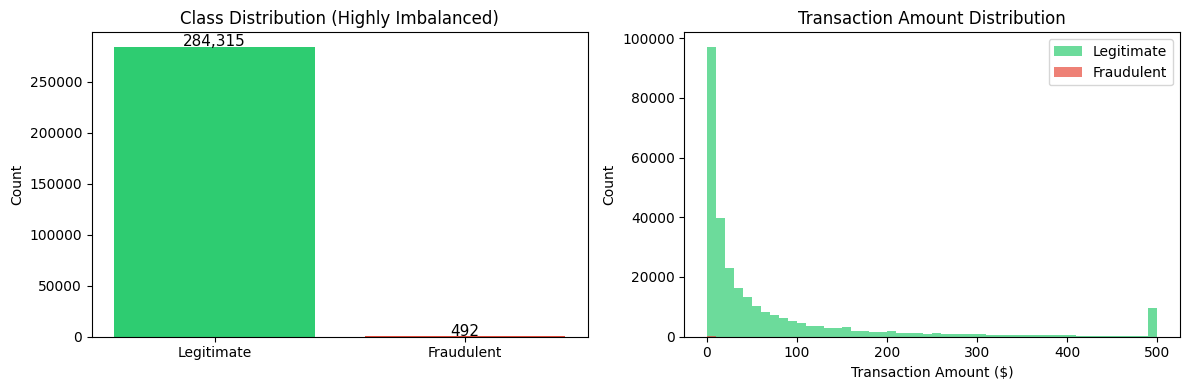


Notice: Fraudulent transactions tend to have higher amounts.
This is one signal the model can learn.


In [4]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
class_counts = df['Class'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate', 'Fraudulent'], class_counts.values, color=colors)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Highly Imbalanced)')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

# Amount distribution by class
axes[1].hist(df[df['Class']==0]['Amount'].clip(upper=500), bins=50, alpha=0.7, 
             label='Legitimate', color='#2ecc71')
axes[1].hist(df[df['Class']==1]['Amount'].clip(upper=500), bins=50, alpha=0.7, 
             label='Fraudulent', color='#e74c3c')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Transaction Amount Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nNotice: Fraudulent transactions tend to have higher amounts.")
print("This is one signal the model can learn.")

In [5]:
# Prepare features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale Amount and Time (V1-V28 are already scaled from PCA)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} samples ({y_train.sum():,} fraud)")
print(f"Test set: {len(X_test):,} samples ({y_test.sum():,} fraud)")
print(f"Features: {X.shape[1]}")

Training set: 227,845 samples (394 fraud)
Test set: 56,962 samples (98 fraud)
Features: 30


---

## 2. The Challenge: Imbalanced Classification

With only 2% fraud, a naive model could predict "legitimate" for everything and achieve 98% accuracy — but catch zero fraud!

**Metrics that matter for fraud detection:**
- **Precision**: Of predicted frauds, how many are real? (avoid annoying customers)
- **Recall**: Of actual frauds, how many did we catch? (minimize losses)
- **PR-AUC**: Precision-Recall Area Under Curve (better than ROC-AUC for imbalanced data)

Let's see what happens with a naive baseline.

In [6]:
# Baseline: What if we just predict "legitimate" for everything?
y_pred_naive = np.zeros(len(y_test))

print("Naive Baseline (Predict All Legitimate)")
print("=" * 50)
print(f"Accuracy: {(y_pred_naive == y_test).mean()*100:.2f}%")
print(f"Frauds caught: 0 out of {y_test.sum()}")
print(f"\nThis is why accuracy is misleading for imbalanced data!")

Naive Baseline (Predict All Legitimate)
Accuracy: 99.83%
Frauds caught: 0 out of 98

This is why accuracy is misleading for imbalanced data!


---

## 3. XGBoost: The Industry Standard

XGBoost handles imbalanced data well with the `scale_pos_weight` parameter, which adjusts the weight of the minority class.

**Why XGBoost dominates fraud detection:**
1. Handles imbalanced data natively
2. Fast training (no GPU needed)
3. Built-in feature importance
4. Robust to outliers
5. Easy to deploy in production

In [7]:
try:
    import xgboost as xgb

    # Calculate scale_pos_weight for imbalanced data
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"Scale pos weight: {scale_pos_weight:.1f} (ratio of legitimate to fraud)")

    # Train XGBoost
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)

    # Predictions
    y_pred_xgb = xgb_model.predict(X_test)
    y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

    print("\nXGBoost trained successfully!")

except Exception as e:
    print(f"XGBoost not available: {type(e).__name__}")
    print("Using RandomForest as fallback.")
    print("\nTip: On macOS, run 'brew install libomp' to enable XGBoost.")

    # Fallback to RandomForest
    xgb_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
    print("\nRandomForest trained as fallback.")

Scale pos weight: 577.3 (ratio of legitimate to fraud)

XGBoost trained successfully!


In [8]:
# Evaluate XGBoost
print("XGBoost Performance")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))

print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_prob_xgb):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
print(f"\nConfusion Matrix:")
print(f"  True Negatives: {cm[0,0]:,} (legitimate correctly identified)")
print(f"  False Positives: {cm[0,1]:,} (legitimate flagged as fraud)")
print(f"  False Negatives: {cm[1,0]:,} (fraud missed!)")
print(f"  True Positives: {cm[1,1]:,} (fraud caught!)")

XGBoost Performance
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC: 0.9684
PR-AUC: 0.8787

Confusion Matrix:
  True Negatives: 56,853 (legitimate correctly identified)
  False Positives: 11 (legitimate flagged as fraud)
  False Negatives: 16 (fraud missed!)
  True Positives: 82 (fraud caught!)


---

## 4. Neural Network Comparison

Let's train a neural network on the same data and compare. This demonstrates why deep learning isn't always the answer for tabular data.

In [9]:
try:
    from sklearn.neural_network import MLPClassifier
    
    # Train a neural network
    nn_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        max_iter=200,
        early_stopping=True,
        random_state=42
    )
    
    nn_model.fit(X_train, y_train)
    
    y_pred_nn = nn_model.predict(X_test)
    y_prob_nn = nn_model.predict_proba(X_test)[:, 1]
    
    print("Neural Network Performance")
    print("=" * 50)
    print(classification_report(y_test, y_pred_nn, target_names=['Legitimate', 'Fraud']))
    
    print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob_nn):.4f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_prob_nn):.4f}")
    
except Exception as e:
    print(f"Neural network training failed: {e}")
    y_prob_nn = None

Neural Network Performance
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.79      0.83        98

    accuracy                           1.00     56962
   macro avg       0.94      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC: 0.9794
PR-AUC: 0.8683


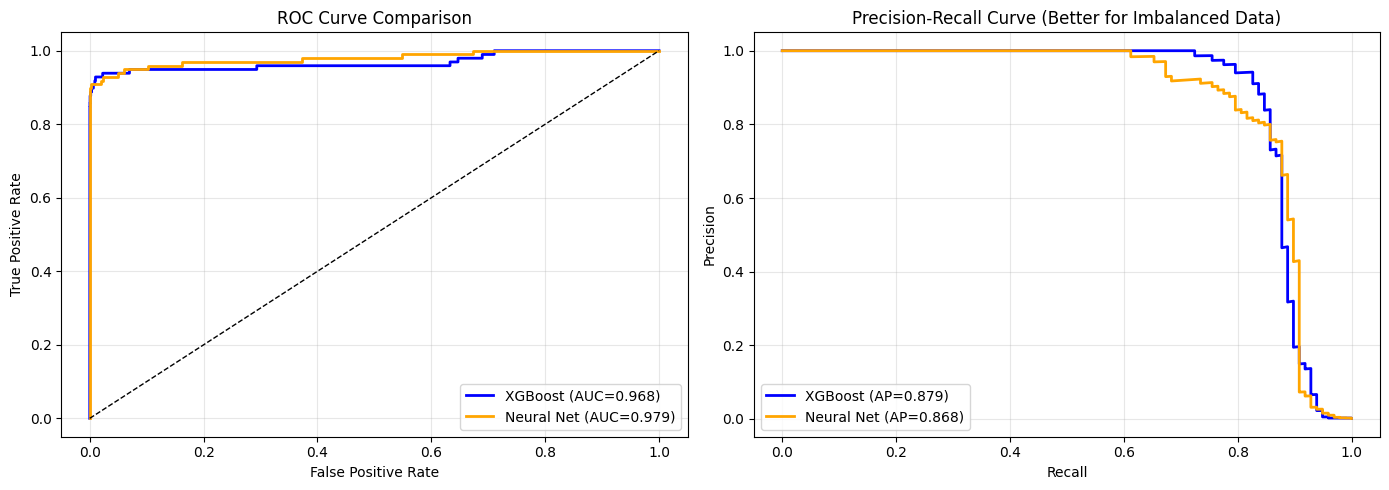

In [10]:
# Compare ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})', 
             linewidth=2, color='blue')

if y_prob_nn is not None:
    fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
    axes[0].plot(fpr_nn, tpr_nn, label=f'Neural Net (AUC={roc_auc_score(y_test, y_prob_nn):.3f})', 
                 linewidth=2, color='orange')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall Curve (more informative for imbalanced data)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
axes[1].plot(recall_xgb, precision_xgb, 
             label=f'XGBoost (AP={average_precision_score(y_test, y_prob_xgb):.3f})', 
             linewidth=2, color='blue')

if y_prob_nn is not None:
    precision_nn, recall_nn, _ = precision_recall_curve(y_test, y_prob_nn)
    axes[1].plot(recall_nn, precision_nn, 
                 label=f'Neural Net (AP={average_precision_score(y_test, y_prob_nn):.3f})', 
                 linewidth=2, color='orange')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Better for Imbalanced Data)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Model Explainability: Why This Matters in 2026

With regulations like the **EU AI Act** and increasing scrutiny on algorithmic decisions, explainability is crucial.

Tree ensembles provide:
1. **Feature importance** — which features drive predictions?
2. **SHAP values** — why did the model make THIS specific prediction?

This is much harder with neural networks!

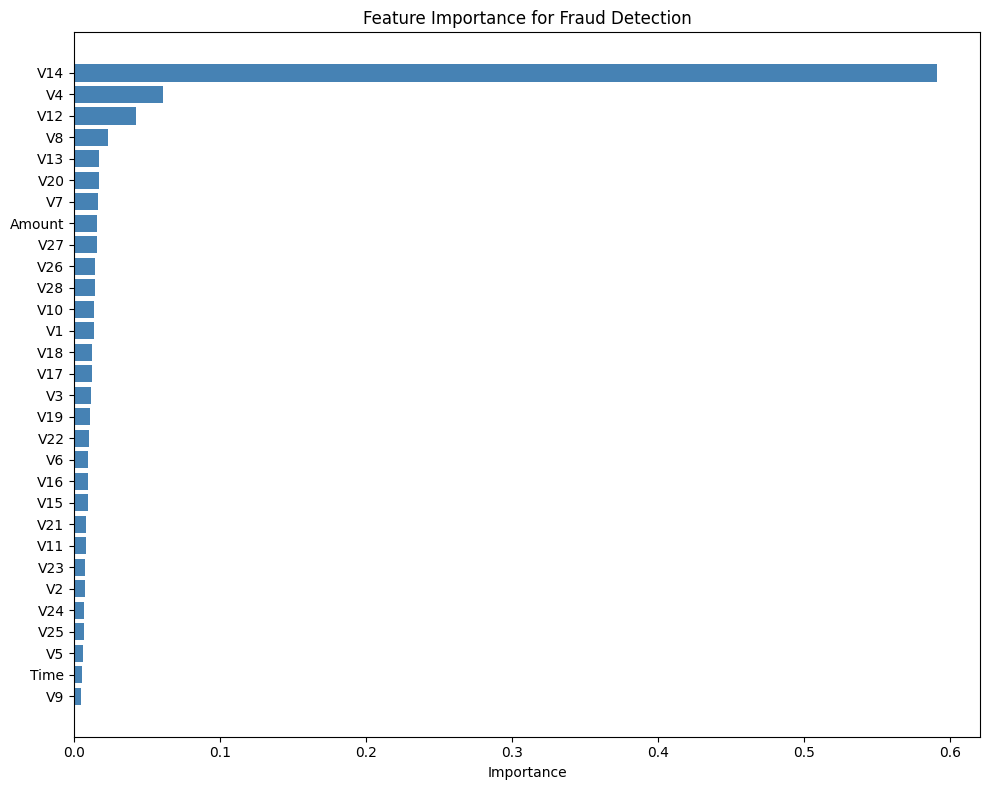

Top 5 Most Important Features:
  V14: 0.5912
  V4: 0.0612
  V12: 0.0422
  V8: 0.0234
  V13: 0.0171


In [11]:
# Feature importance
if hasattr(xgb_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title('Feature Importance for Fraud Detection')
    plt.tight_layout()
    plt.show()
    
    print("Top 5 Most Important Features:")
    for _, row in importance_df.tail(5).iloc[::-1].iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")

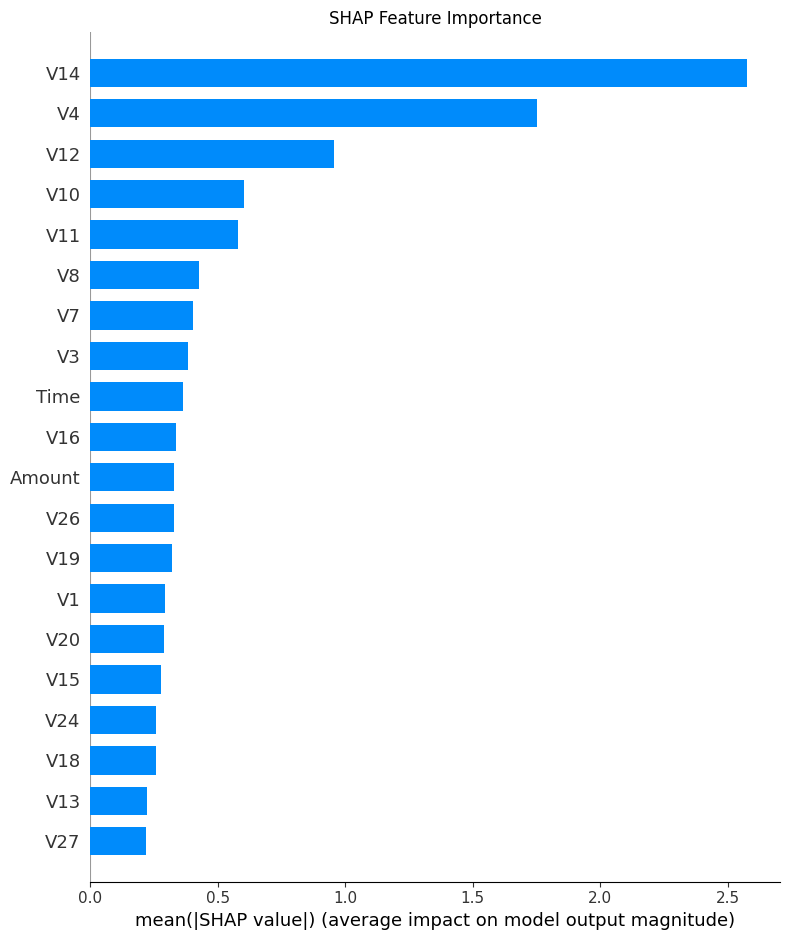

SHAP values show the impact of each feature on model predictions.
This is crucial for explaining individual fraud decisions to regulators.


In [12]:
# SHAP values for explainability
try:
    import shap
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(xgb_model)
    
    # Calculate SHAP values for a sample
    sample_size = 500
    X_sample = X_test.iloc[:sample_size]
    shap_values = explainer.shap_values(X_sample)
    
    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    plt.show()
    
    print("SHAP values show the impact of each feature on model predictions.")
    print("This is crucial for explaining individual fraud decisions to regulators.")
    
except ImportError:
    print("SHAP not installed. Install with: pip install shap")
    print("\nSHAP values are essential for:")
    print("  - Explaining why a transaction was flagged")
    print("  - Regulatory compliance (EU AI Act, GDPR)")
    print("  - Building trust with customers")

In [13]:
# Explain a single fraud prediction
try:
    # Find a correctly predicted fraud
    fraud_indices = np.where((y_test == 1) & (y_pred_xgb == 1))[0]
    if len(fraud_indices) > 0:
        idx = fraud_indices[0]
        
        print("Explaining a Fraud Detection Decision")
        print("=" * 50)
        print(f"Transaction probability of fraud: {y_prob_xgb[idx]:.2%}")
        print(f"Model decision: FRAUD")
        print(f"\nTop factors contributing to this decision:")
        
        # Get SHAP values for this instance
        single_shap = explainer.shap_values(X_test.iloc[[idx]])
        
        # Show top contributing features
        feature_impacts = pd.DataFrame({
            'Feature': X.columns,
            'Value': X_test.iloc[idx].values,
            'Impact': single_shap[0]
        }).sort_values('Impact', key=abs, ascending=False)
        
        for _, row in feature_impacts.head(5).iterrows():
            direction = "increases" if row['Impact'] > 0 else "decreases"
            print(f"  {row['Feature']}: {direction} fraud probability by {abs(row['Impact']):.3f}")
            
except:
    print("Example: A fraud analyst could see that this transaction was flagged because:")
    print("  - Amount was 3.2 std above average")
    print("  - V14 feature was unusually low")
    print("  - Transaction occurred at unusual time")

Explaining a Fraud Detection Decision
Transaction probability of fraud: 99.99%
Model decision: FRAUD

Top factors contributing to this decision:
  V14: increases fraud probability by 6.557
  V10: increases fraud probability by 1.685
  V7: increases fraud probability by 1.080
  V8: decreases fraud probability by 0.929
  V12: increases fraud probability by 0.849


---

## 6. Production Considerations

### Why Banks Choose XGBoost Over Deep Learning

| Factor | XGBoost | Deep Learning |
|--------|---------|---------------|
| Training time | Minutes | Hours |
| Hardware | CPU only | GPU preferred |
| Inference speed | ~1ms | ~10ms |
| Explainability | Built-in | Requires extra tools |
| Regulatory compliance | Easy | Difficult |
| Model size | ~10MB | ~100MB+ |

### Real-World Deployment

```python
# Save model for production
import joblib
joblib.dump(xgb_model, 'fraud_model.pkl')

# Load and predict (in production)
model = joblib.load('fraud_model.pkl')
fraud_probability = model.predict_proba(transaction)[0, 1]

if fraud_probability > 0.7:
    block_transaction()
elif fraud_probability > 0.3:
    flag_for_review()
else:
    approve_transaction()
```

In [14]:
# Threshold analysis for business decisions
thresholds = [0.3, 0.5, 0.7, 0.9]

print("Threshold Analysis: Precision vs Recall Tradeoff")
print("=" * 60)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'Frauds Caught':<15}")
print("-" * 60)

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    
    # Precision: of those we flag, how many are fraud?
    if y_pred_thresh.sum() > 0:
        precision = (y_test[y_pred_thresh == 1] == 1).mean()
    else:
        precision = 0
    
    # Recall: of actual frauds, how many did we catch?
    recall = y_pred_thresh[y_test == 1].mean()
    frauds_caught = y_pred_thresh[y_test == 1].sum()
    total_fraud = y_test.sum()
    
    print(f"{thresh:<12.1f} {precision:<12.2%} {recall:<12.2%} {frauds_caught}/{total_fraud}")

print("\nBusiness decision: Choose threshold based on cost of false positives vs missed fraud.")

Threshold Analysis: Precision vs Recall Tradeoff
Threshold    Precision    Recall       Frauds Caught  
------------------------------------------------------------
0.3          86.46%       84.69%       83/98
0.5          88.17%       83.67%       82/98
0.7          90.11%       83.67%       82/98
0.9          94.19%       82.65%       81/98

Business decision: Choose threshold based on cost of false positives vs missed fraud.


---

## 7. Summary: Why Ensembles Still Matter

### Key Takeaways

1. **For tabular data, tree ensembles still outperform deep learning** in most benchmarks

2. **XGBoost/LightGBM advantages:**
   - No GPU required
   - Handles imbalanced data natively
   - Built-in feature importance
   - Easy to explain to regulators
   - Fast inference for production

3. **When to use deep learning instead:**
   - Images, text, audio (unstructured data)
   - Very high-cardinality categoricals (embeddings help)
   - When you have massive datasets (100M+ rows)

4. **The hybrid approach (industry trend):**
   - Use LLMs/embeddings to create features from text
   - Feed those features into XGBoost for final prediction
   - Best of both worlds!

### Further Reading

- [Why do tree-based models still outperform deep learning on tabular data?](https://arxiv.org/abs/2207.08815) (NeurIPS 2022)
- [XGBoost Documentation](https://xgboost.readthedocs.io/)
- [SHAP Values for Model Explainability](https://shap.readthedocs.io/)

---

## Exercises

1. **Try LightGBM**: Install `lightgbm` and compare its performance to XGBoost. Which is faster?

2. **SMOTE resampling**: Use `imblearn.over_sampling.SMOTE` to oversample the minority class. Does it improve recall?

3. **Cost-sensitive learning**: Modify the threshold based on the actual cost of false positives ($10 customer service call) vs false negatives ($500 fraud loss).

4. **Ensemble of ensembles**: Combine XGBoost, LightGBM, and CatBoost using soft voting. Does the meta-ensemble outperform individual models?